In [ ]:
# 필요한 라이브러리 임포트
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import os
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import random


In [ ]:
# device 설정 (GPU가 있으면 GPU 사용)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("사용하는 device:", device)

# MNIST 데이터셋 준비
# 데이터 전처리를 위해 ToTensor 변환을 적용
transform = transforms.Compose([transforms.ToTensor()])

# 학습용 MNIST 데이터셋 다운로드 및 로드
trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
trainloader = DataLoader(trainset, batch_size=256, shuffle=True)


사용하는 device: cuda


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

### VAE (Variational Autoencoder) 모델 정의 ###
class VAE(nn.Module):
    def __init__(self, latent_dim=2):
        """
        VAE 모델의 구조를 정의하고 모든 구성 요소(신경망 레이어)를 초기화하는 생성자 함수입니다.
        이 함수는 모델 객체가 처음 생성될 때 단 한 번만 호출됩니다.

        매개변수:
            latent_dim (int): 잠재 공간(latent space)의 차원.
                               이 값은 원본 데이터가 얼마나 압축될지를 결정합니다.
                               예를 들어, 784개의 픽셀(28*28)로 이루어진 MNIST 이미지를 단 2개의 숫자(latent_dim=2)로 압축하여 표현하게 됩니다.
                               이 2차원 공간에 데이터의 핵심 특징들이 인코딩됩니다.
        """
        super(VAE, self).__init__()

        # ==========================================================================================
        # 1. 인코더 (Encoder) 정의
        # 역할: 입력 데이터를 저차원의 잠재 공간으로 보내는 '확률 분포'로 압축합니다.
        # 일반적인 오토인코더처럼 한 점으로 압축하는 것이 아니라, "이 데이터는 잠재 공간의 이쯤에, 이 정도의 불확실성을 가지고 존재할 거야" 라는
        # '분포' 정보(평균과 분산)를 출력하는 것이 VAE의 가장 큰 특징입니다.
        # ==========================================================================================

        # 첫 번째 Fully Connected Layer.
        # 28*28=784 차원의 입력 이미지 벡터를 400 차원의 중간 표현(hidden representation)으로 변환합니다.
        # 이 레이어는 이미지의 복잡한 픽셀 패턴에서 더 의미 있는 특징들을 추출하는 역할을 시작합니다.
        self.fc1 = nn.Linear(28 * 28, 400)

        # 인코더의 최종 출력단. 여기서 VAE의 핵심적인 분기가 일어납니다.
        # 중간 표현(400차원)을 입력받아, 잠재 공간의 분포를 정의하는 두 개의 파라미터를 각각 출력합니다.

        # self.fc21: 잠재 변수의 '평균(mu, μ)'을 출력합니다.
        # 이는 압축된 데이터가 잠재 공간의 어느 '중심점'에 위치하는지를 나타냅니다.
        self.fc21 = nn.Linear(400, latent_dim)

        # self.fc22: 잠재 변수의 '로그 분산(log variance, log σ^2)'을 출력합니다.
        # 분산은 데이터가 중심점에서 얼마나 퍼져있는지(불확실성)를 나타냅니다.
        # 직접 분산을 출력하지 않고 '로그 분산'을 출력하는 이유는,
        # 1) 분산(σ^2)은 항상 양수여야 하는데, 신경망 출력은 음수가 될 수 있기 때문입니다. logvar를 계산한 뒤 exp()를 취하면 항상 양수가 보장됩니다 (σ^2 = exp(log(σ^2))).
        # 2) 학습의 수치적 안정성을 높여줍니다.
        self.fc22 = nn.Linear(400, latent_dim)

        # ==========================================================================================
        # 2. 디코더 (Decoder) 정의
        # 역할: 잠재 공간의 한 점(벡터)을 다시 원본 데이터의 차원으로 복원(생성)합니다.
        # 인코더가 압축한 정보를 바탕으로 '그럴듯한' 원본 이미지를 재구성하는 역할을 합니다.
        # ==========================================================================================

        # 첫 번째 디코더 레이어.
        # latent_dim 차원의 잠재 변수 z를 입력받아 400 차원의 중간 표현으로 확장합니다.
        # 이는 압축된 핵심 특징으로부터 다시 이미지의 구체적인 형태를 만들어내기 시작하는 단계입니다.
        self.fc3 = nn.Linear(latent_dim, 400)

        # 최종 디코더 레이어.
        # 400 차원의 중간 표현을 원래 이미지 크기인 28*28=784 차원으로 복원합니다.
        self.fc4 = nn.Linear(400, 28 * 28)

    def encode(self, x):
        """
        인코딩 함수: 입력 x를 인코더 신경망에 통과시켜 잠재 변수의 평균(mu)과 로그 분산(logvar)을 출력합니다.
        이것이 VAE의 '추론 네트워크(Inference Network)' 또는 '인식 모델(Recognition Model)'이라고도 불리는 부분입니다.

        매개변수:
            x (Tensor): 모델에 입력되는 데이터 (이미지 벡터).

        반환값:
            (Tensor, Tensor): 잠재 변수의 평균(mu), 잠재 변수의 로그 분산(logvar).
        """
        # 입력 x를 fc1 레이어에 통과시키고, 비선형성을 추가하기 위해 ReLU 활성화 함수를 적용합니다.
        # ReLU는 음수 값을 0으로 만들어 신경망의 표현력을 높여줍니다.
        h1 = F.relu(self.fc1(x))

        # 중간 표현 h1을 각각 평균(mu)과 로그 분산(logvar)을 계산하는 레이어에 통과시켜 결과를 반환합니다.
        # 이 두 값이 바로 입력 x가 잠재 공간에서 어떤 '확률 분포'를 갖는지를 정의합니다.
        return self.fc21(h1), self.fc22(h1)

    def reparameterize(self, mu, logvar):
        """
        재파라미터화 트릭 (Reparameterization Trick): VAE 학습의 핵심 기술.
        역전파가 불가능한 '샘플링' 과정을, 미분이 가능한 '결정적인 연산'으로 우회하는 방법입니다.

        기존 방식: z ~ N(μ, σ²)  <- '샘플링' 연산은 미분 불가. μ, σ로 그래디언트가 흐를 수 없음.
        트릭 적용: z = μ + ε * σ (여기서 ε ~ N(0, 1)) <- z와 μ, σ의 관계가 덧셈, 곱셈으로 바뀌어 미분 가능!

        이 함수를 통해 우리는 손실(loss)로부터 인코더의 파라미터(μ, logvar를 출력하는 레이어)까지 역전파를 수행할 수 있게 됩니다.
        """
        # 1. 표준편차(std) 계산
        # logvar는 log(σ^2) 이므로, σ를 계산하기 위해 exp()와 제곱근을 사용해야 합니다.
        # log(σ^2) * 0.5 = (1/2)log(σ^2) = log( (σ^2)^(1/2) ) = log(σ)
        # 따라서 torch.exp(0.5 * logvar)는 exp(log(σ))가 되어 최종적으로 σ (표준편차)가 됩니다.
        std = torch.exp(0.5 * logvar)

        # 2. 표준 정규분포로부터 노이즈(epsilon, ε) 생성
        # std와 동일한 크기의 텐서를 만들고, 그 안을 평균 0, 표준편차 1인 정규분포에서 추출한 값들로 채웁니다.
        # 이 부분이 바로 외부에서 주입되는 '순수한 무작위성'입니다.
        eps = torch.randn_like(std)

        # 3. 최종 잠재 변수 z 계산
        # z = μ + ε * σ 공식을 그대로 코드로 구현합니다.
        # 이제 z는 μ와 std(logvar로부터 계산됨)에 대해 미분 가능한 함수가 되었습니다.
        # 학습 시, 역전파 과정에서 eps는 상수로 취급되고, mu와 std를 통해 인코더의 가중치가 업데이트됩니다.
        return mu + eps * std

    def decode(self, z):
        """
        디코딩 함수: 잠재 변수 z를 디코더 신경망에 통과시켜 원본 이미지와 같은 차원의 결과물로 복원(생성)합니다.
        이것이 VAE의 '생성 네트워크(Generative Network)'라고도 불리는 부분입니다.

        매개변수:
            z (Tensor): 재파라미터화 트릭을 통해 샘플링된 잠재 변수.

        반환값:
            (Tensor): 복원된 이미지. 픽셀 값은 0과 1 사이입니다.
        """
        # 잠재 변수 z를 fc3 레이어에 통과시키고 ReLU 활성화 함수를 적용하여 중간 표현으로 확장합니다.
        h3 = F.relu(self.fc3(z))

        # h3를 최종 레이어 fc4에 통과시킨 후, 시그모이드(Sigmoid) 활성화 함수를 적용합니다.
        # 시그모이드 함수는 모든 출력 값을 0과 1 사이로 압축하는 역할을 합니다.
        # MNIST 이미지의 픽셀 값이 0(검은색)과 1(흰색) 사이로 정규화되어 있기 때문에,
        # 모델의 출력 역시 동일한 범위의 값을 갖도록 만들어주는 것이 중요합니다.
        return torch.sigmoid(self.fc4(h3))

    def forward(self, x):
        """
        순전파 함수: 모델의 전체 데이터 흐름을 정의합니다.
        입력 데이터 x가 들어왔을 때, 위에서 정의한 encode, reparameterize, decode 함수를 순서대로 거쳐
        최종 결과물을 반환하는 과정을 명시합니다.

        PyTorch 모델을 호출하면 (예: model(data)) 이 forward 함수가 자동으로 실행됩니다.

        반환값:
            (Tensor, Tensor, Tensor): 복원된 이미지(recon_x), 잠재 변수의 평균(mu), 잠재 변수의 로그 분산(logvar).
                                      이 세 가지 값은 모두 손실 함수(loss function)를 계산하는 데 사용됩니다.
        """
        # 1. 인코딩
        # 입력 이미지 x를 1차원 벡터로 펼칩니다 (예: [배치크기, 28, 28] -> [배치크기, 784]).
        # 그리고 encode 함수를 호출하여 평균(mu)과 로그 분산(logvar)을 얻습니다.
        mu, logvar = self.encode(x.view(-1, 28 * 28))

        # 2. 재파라미터화 (샘플링)
        # 얻어진 mu와 logvar를 reparameterize 함수에 넣어 잠재 변수 z를 샘플링합니다.
        z = self.reparameterize(mu, logvar)

        # 3. 디코딩
        # 샘플링된 z를 decode 함수에 넣어 최종 이미지를 복원(생성)합니다.
        # 이 반환값이 손실 함수의 '복원 손실(Reconstruction Loss)'을 계산하는 데 사용됩니다.
        # mu와 logvar는 'KL 발산(KL Divergence)' 손실을 계산하는 데 사용됩니다.
        return self.decode(z), mu, logvar

In [ ]:
import torch
import torch.nn.functional as F

### 손실 함수 정의 ###

# beta-VAE에서 사용되는 하이퍼파라미터입니다.
# VAE의 손실 함수는 '복원'과 '정규화'라는 두 가지 목표 사이의 균형을 맞추는 줄다리기와 같습니다.
# beta 값은 이 줄다리기에서 KL 손실(정규화) 쪽의 힘을 얼마나 강하게 할지 조절하는 '가중치'입니다.
# - beta = 1.0 : 일반적인 VAE입니다. 복원과 정규화의 균형을 맞춥니다.
# - beta > 1.0 : KL 손실에 더 큰 페널티를 부여합니다. 이는 잠재 공간을 더 강하게 정규화하여,
#                각 차원이 독립적이고 해석 가능한 특징(disentangled representation)을 학습하도록 유도합니다.
#                하지만 너무 크면 복원 품질이 저하될 수 있습니다.
# - beta < 1.0 : 복원 손실에 더 집중하게 만듭니다. 복원 품질은 올라갈 수 있으나,
#                잠재 공간의 구조가 무너져 새로운 데이터를 생성하는 능력이 떨어질 수 있습니다.
beta = 1.0

def loss_function(recon_x, x, mu, logvar):
    """
    VAE의 최종 목표인 ELBO(Evidence Lower Bound)를 최대화하기 위한 손실 함수입니다.
    ELBO를 최대화하는 것은 아래의 두 가지 손실 항의 합을 '최소화'하는 것과 수학적으로 동일합니다.

    1. 복원 손실 (Reconstruction Loss): 디코더가 원본을 얼마나 잘 복원했는가?
    2. KL 발산 손실 (KL Divergence Loss): 인코더가 잠재 공간을 얼마나 예쁘게 정돈했는가?

    매개변수:
        recon_x (Tensor): 모델이 복원한 이미지 (디코더의 출력)
        x (Tensor): 원본 이미지 (학습 데이터)
        mu (Tensor): 잠재 변수의 평균 (인코더의 출력)
        logvar (Tensor): 잠재 변수의 로그 분산 (인코더의 출력)
    """

    # ==========================================================================================
    # 1. 복원 손실 (Reconstruction Loss) 계산
    # 목표: 원본 이미지(x)와 디코더가 복원한 이미지(recon_x)를 최대한 똑같이 만든다.
    # 방법: 두 이미지의 픽셀 값 차이를 측정합니다.
    # ==========================================================================================

    # F.binary_cross_entropy 함수를 사용하여 픽셀 단위의 차이를 계산합니다.
    # BCE는 두 확률 분포(여기서는 0~1 사이 값을 갖는 이미지 픽셀) 간의 차이를 측정하는 데 효과적입니다.
    # recon_x: 디코더의 출력. sigmoid를 통과했으므로 0~1 사이의 값을 가집니다.
    # x.view(-1, 28 * 28): 원본 이미지. [배치 크기, 784] 형태로 펼쳐서 recon_x와 크기를 맞춰줍니다.
    # reduction='sum': 기본적으로 BCE는 픽셀별 손실의 '평균'을 계산하지만, VAE 논문에서는 '합(sum)'을 사용합니다.
    #                  이는 각 픽셀 하나하나를 독립적인 베르누이 분포로 간주하고 전체 이미지의 로그 가능도를 계산하는 것과 같습니다.
    #                  배치의 모든 이미지, 모든 픽셀에 대한 손실을 전부 더합니다.
    BCE = F.binary_cross_entropy(recon_x, x.view(-1, 28 * 28), reduction='sum')

    # ==========================================================================================
    # 2. KL 발산 손실 (KL Divergence Loss) 계산
    # 목표: 인코더가 만든 분포 q(z|x) = N(μ, σ²)를 기준 분포 p(z) = N(0, 1)에 가깝게 만든다.
    # 역할: 잠재 공간에 '규제(regularization)'를 가하여, 데이터들이 원점(0,0) 근처에 적절히 흩어져 있도록 정돈합니다.
    #       이 덕분에 잠재 공간이 연속적이고 부드러워져, 새로운 데이터를 생성할 수 있게 됩니다.
    # ==========================================================================================

    # 아래 수식은 N(μ, σ²)와 N(0, 1) 사이의 KL Divergence를 분석적으로 계산한 결과입니다.
    # 수학 공식: KLD = 0.5 * Σ ( σ² + μ² - 1 - log(σ²) )
    # 여기서 log(σ²)는 코드의 'logvar'에 해당하고, σ²는 'logvar.exp()'에 해당합니다.
    #
    # KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    #
    # 위 코드와 수학 공식의 부호와 항의 순서가 다른 이유:
    # 1) 수학 공식의 (σ² + μ² - 1 - log(σ²))를 (-1)로 묶으면 -(1 + log(σ²) - μ² - σ²)가 됩니다.
    # 2) 여기에 0.5 * Σ 대신 -0.5 * torch.sum()을 사용했으므로 최종적으로 동일한 수식이 됩니다.
    #    즉, -0.5 * Σ (1 + logvar - mu^2 - exp(logvar)) 와 같습니다.
    #
    # torch.sum(): BCE와 마찬가지로, 배치의 모든 데이터와 모든 잠재 차원(latent_dim)에 대한 KLD 값을 전부 더합니다.
    # 각 항의 직관적 의미:
    # - mu.pow(2): 평균(μ)이 0에서 멀어질수록 손실이 커집니다 (μ를 0으로 보내려는 힘).
    # - logvar.exp(): 분산(σ²)이 1보다 커지거나 작아질수록 손실이 커집니다 (σ²을 1로 보내려는 힘).
    # - 1 + logvar: 로그 항으로, 분산이 1일 때(logvar=0) 전체 값이 최소가 되도록 돕는 역할.
    KLD = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

    # ==========================================================================================
    # 3. 최종 손실 반환
    # 두 손실을 합쳐 최종 손실을 계산합니다.
    # 옵티마이저는 이 최종 손실 값을 최소화하는 방향으로 모델의 모든 파라미터(인코더, 디코더의 가중치)를 업데이트합니다.
    # ==========================================================================================
    return BCE + beta * KLD

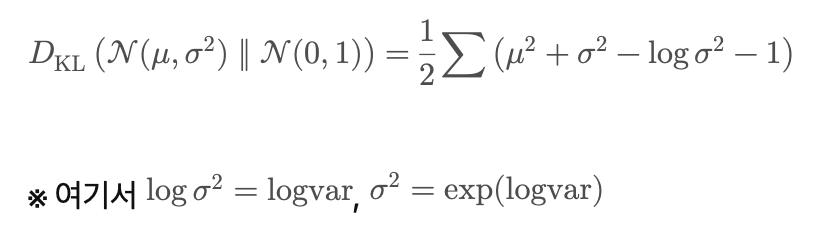

#### KL 발산 : N(u, sigma^2), N(0, 1)

두 정규분포 $q(z) = {N}(\mu, \sigma^2)$와 $p(z) = {N}(0,1)$의 KL 발산을 계산해보면:

1. **정의부터 시작합니다.**  
   일반적인 KL 발산의 정의는  
   $
   D_{\text{KL}}(q(z) \parallel p(z)) = \int q(z) \log \frac{q(z)}{p(z)} \, dz
   $  
   입니다.

2. **각 분포의 확률 밀도 함수를 대입합니다.**  
   - q(z)의 밀도:  
     $
     q(z) = \frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(z-\mu)^2}{2\sigma^2}\right)
     $
   - p(z)의 밀도:  
     $
     p(z) = \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{z^2}{2}\right)
     $

3. **로그의 차이를 계산합니다.**  
   $
   \log \frac{q(z)}{p(z)} = \log\left(\frac{1}{\sqrt{2\pi\sigma^2}} \exp\left(-\frac{(z-\mu)^2}{2\sigma^2}\right) \Big/ \frac{1}{\sqrt{2\pi}} \exp\left(-\frac{z^2}{2}\right)\right)
   $\
   여기서 로그를 분리하면,  
   $log \frac{q(z)}{p(z)} = -\frac{1}{2}\log(\sigma^2) -\frac{(z-\mu)^2}{2\sigma^2} + \frac{z^2}{2}
   $

4. **q(z)에 대해 기댓값을 취하는 적분을 수행하면,**  
   여러 표준적 통계량(예, $\mathbb{E}_{q}[z] = \mu, \mathbb{E}_{q}[z^2] = \mu^2+\sigma^2$)을 사용하여, 적분 결과가  
   $
   D_{\text{KL}}(q(z) \parallel p(z)) = \frac{1}{2}\left(\mu^2 + \sigma^2 - 1 - \log \sigma^2\right)
   $
   로 나오게 됩니다.

5. **다변량일 경우**  
   각 차원마다 위와 같은 계산을 진행하면, 최종 식은  
   $
   D_{\text{KL}}(q(z|x) \parallel p(z)) = \frac{1}{2} \sum_{i=1}^{d} \left( \mu_i^2 + \sigma_i^2 - 1 - \log \sigma_i^2 \right)
   $
   가 됩니다.


In [ ]:
import torch
import torch.optim as optim
# VAE, loss_function, trainloader, device 등은 이전에 정의되었다고 가정합니다.

### 모델 학습: 2D 잠재 공간으로 학습 ###

# 1. 모델 및 옵티마이저 초기화
# ==========================================================================================

# 잠재 공간(latent space)의 차원을 2로 설정합니다.
# 784개의 픽셀 정보를 단 2개의 숫자로 압축하겠다는 의미입니다.
# 왜 2차원으로 할까요? -> 학습이 끝난 후, 2차원 평면에 잠재 벡터들을 시각화하여
# 숫자 클래스들이 어떻게 분포하는지 한눈에 쉽게 확인하기 위함입니다.
latent_dim = 2

# 위에서 정의한 VAE 클래스를 이용해 모델 객체를 생성합니다.
# latent_dim을 인자로 전달하여 2차원 잠재 공간을 갖는 모델을 만듭니다.
# .to(device)는 모델의 모든 파라미터(가중치)를 GPU 또는 CPU로 보내 연산을 준비시킵니다.
model = VAE(latent_dim=latent_dim).to(device)

# 옵티마이저(Optimizer)를 정의합니다. 옵티마이저는 '헬스 트레이너'와 같습니다.
# 역할: 계산된 손실(loss)을 바탕으로, 모델의 가중치(근육)를 가장 효율적인 방향으로 업데이트(성장)시키는 방법을 결정합니다.
# optim.Adam: Adam은 현재 가장 널리 쓰이는 효율적인 옵티마이저 중 하나입니다. (Adaptive Moment Estimation)
# model.parameters(): 옵티마이저에게 "이 모델의 모든 학습 가능한 가중치들을 네가 관리해줘" 라고 알려주는 것입니다.
# lr=1e-3: 학습률(Learning Rate). 가중치를 한 번에 얼마나 크게 업데이트할지 결정하는 보폭(step size)입니다. 너무 크면 발산하고, 너무 작으면 학습이 느립니다.
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 학습을 총 몇 번 반복할지(에포크 수)를 설정합니다.
# 1 에포크(epoch)는 전체 학습 데이터셋을 처음부터 끝까지 한 번 모두 사용하는 것을 의미합니다.
num_epochs = 100

# 2. 학습 루프 (Training Loop) 시작
# ==========================================================================================

print("2D 잠재 공간으로 학습 시작...")
# 총 num_epochs 만큼 전체 데이터셋을 반복하여 학습합니다.
for epoch in range(num_epochs):

    # --- 1. 모델을 '학습 모드'로 전환 ---
    # model.train()을 호출하면 모델의 모든 모듈(레이어)이 학습 모드로 설정됩니다.
    # 이는 드롭아웃(Dropout)이나 배치 정규화(Batch Normalization)와 같이
    # 학습 시와 평가 시에 다르게 동작해야 하는 레이어들을 위해 필수적입니다.
    # (이 VAE 모델에는 해당 레이어가 없지만, 항상 명시해주는 것이 좋은 습관입니다.)
    model.train()

    # --- 2. 한 에포크의 총 손실을 기록하기 위한 변수 초기화 ---
    train_loss = 0

    # --- 3. 미니배치(Mini-batch) 단위로 학습 진행 ---
    # trainloader는 전체 데이터를 작은 묶음(미니배치)으로 나누어 제공합니다.
    # for data, _ in trainloader: 이 루프는 한 번 돌 때마다 데이터 한 묶음(예: 128개 이미지)을 가져옵니다.
    # data: 이미지 데이터 텐서.
    # _: 이미지의 실제 레이블(숫자가 7인지, 1인지 등). VAE는 비지도학습이라 레이블이 필요 없으므로 _ 로 받아 무시합니다.
    for data, _ in trainloader:

        # --- 4. 데이터 준비 ---
        # 현재 미니배치 데이터를 모델과 동일한 장치(GPU 또는 CPU)로 보냅니다.
        data = data.to(device)

        # --- 5. 기울기(Gradient) 초기화 ---
        # ★★★ 매우 중요한 단계 ★★★
        # PyTorch는 역전파를 수행할 때마다 새로운 기울기를 '계산'하는 것이 아니라 기존 기울기에 '누적'시킵니다.
        # 따라서 새로운 미니배치에 대한 기울기를 계산하기 전, 이전 배치의 기울기 값을 0으로 깨끗하게 지워야 합니다.
        # 이 줄이 없으면 기울기가 계속 쌓여 학습이 제대로 이루어지지 않습니다.
        optimizer.zero_grad()

        # --- 6. 순전파 (Forward Pass) ---
        # model(data)를 호출하면 VAE 클래스의 forward 함수가 실행됩니다.
        # 데이터가 인코더 -> 재파라미터화 -> 디코더를 거쳐 결과물이 나옵니다.
        # recon_batch: 복원된 이미지
        # mu, logvar: 잠재 공간의 분포 파라미터
        recon_batch, mu, logvar = model(data)

        # --- 7. 손실(Loss) 계산 ---
        # 위에서 나온 결과물들과 원본 데이터를 loss_function에 넣어 현재 배치의 손실을 계산합니다.
        # 손실 값은 모델이 얼마나 '못했는지'를 나타내는 스칼라 값입니다.
        loss = loss_function(recon_batch, data, mu, logvar)

        # --- 8. 역전파 (Backward Pass) ---
        # 계산된 손실을 기준으로, 모델의 모든 파라미터(가중치)에 대한 기울기(gradient)를 자동으로 계산합니다.
        # 즉, "이 손실을 줄이려면 각 가중치를 어느 방향으로 얼마나 조절해야 하는가?"에 대한 정보를 계산하는 과정입니다.
        loss.backward()

        # --- 9. 한 에포크의 총 손실 누적 ---
        # loss는 텐서 객체이므로 순수한 숫자 값만 추출하기 위해 .item()을 사용합니다.
        # 현재 배치의 손실을 train_loss 변수에 더해 한 에포크 동안의 총 손실을 기록합니다.
        train_loss += loss.item()

        # --- 10. 가중치 업데이트 ---
        # 옵티마이저가 loss.backward()를 통해 계산된 기울기 정보를 바탕으로,
        # Adam 알고리즘에 따라 모델의 가중치를 실제로 업데이트(수정)합니다.
        # 이 한 줄을 통해 모델이 비로소 '학습'을 하게 됩니다.
        optimizer.step()

    # --- 11. 한 에포크 학습 완료 후 결과 출력 ---
    # 한 에포크가 끝나면, 누적된 총 손실을 전체 데이터셋의 개수로 나누어
    # '데이터 샘플 1개당 평균 손실'을 계산하고 출력합니다.
    # 이 값을 통해 학습이 잘 진행되고 있는지(손실이 점차 줄어드는지) 모니터링할 수 있습니다.
    print(f'Epoch {epoch + 1}, Loss: {train_loss / len(trainloader.dataset)}')

2D 잠재 공간으로 학습 시작...
Epoch 1, Loss: 204.55721881510416
Epoch 2, Loss: 173.9412814453125
Epoch 3, Loss: 167.48007067057293
Epoch 4, Loss: 164.53532711588542
Epoch 5, Loss: 162.6805030924479
Epoch 6, Loss: 161.26730026041668
Epoch 7, Loss: 160.1373533203125
Epoch 8, Loss: 159.1844308268229
Epoch 9, Loss: 158.31536878255207
Epoch 10, Loss: 157.60732872721354
Epoch 11, Loss: 156.96097154947915
Epoch 12, Loss: 156.38579884440105
Epoch 13, Loss: 155.87486025390626
Epoch 14, Loss: 155.36295696614584
Epoch 15, Loss: 154.946158203125
Epoch 16, Loss: 154.5249918457031
Epoch 17, Loss: 154.19527164713543
Epoch 18, Loss: 153.8206158203125
Epoch 19, Loss: 153.45861469726563
Epoch 20, Loss: 153.2122920735677
Epoch 21, Loss: 152.85908999023437
Epoch 22, Loss: 152.59824833984376
Epoch 23, Loss: 152.39199371744792
Epoch 24, Loss: 152.06107709960938
Epoch 25, Loss: 151.89782797851564
Epoch 26, Loss: 151.65799529622396
Epoch 27, Loss: 151.3781138997396
Epoch 28, Loss: 151.1940602701823
Epoch 29, Loss: 151.

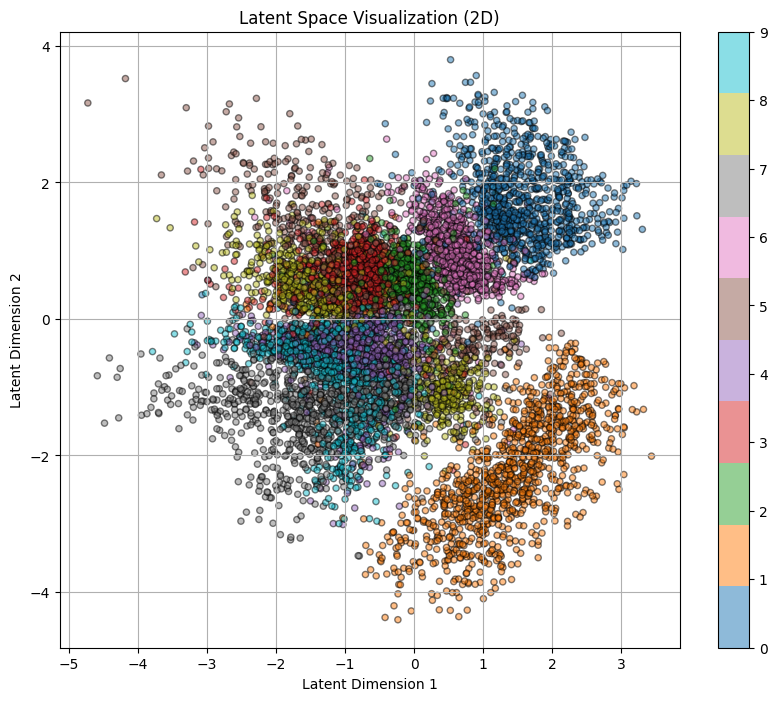

In [ ]:
import torch
import torchvision
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
# VAE, transform, device 등은 이전에 정의되었다고 가정합니다.

### 잠재 공간 시각화 (2D) 및 테스트 데이터셋 처리 ###

# ==========================================================================================
# 1. 평가 준비
# 역할: 모델을 학습 모드가 아닌 '평가 모드'로 전환하고, 결과를 저장할 공간을 마련합니다.
# ==========================================================================================

# 모델을 '평가 모드'로 설정합니다.
# model.eval()은 model.train()의 반대입니다.
# 이 모드에서는 드롭아웃(Dropout)이나 배치 정규화(Batch Normalization) 등의 기능이 비활성화되어,
# 추론 시에 일관된 결과를 얻을 수 있도록 보장합니다.
# "이제부터는 학습 안 하고, 그냥 모델을 사용만 할 거야!" 라고 선언하는 것과 같습니다.
model.eval()

# 시각화를 위해 모든 테스트 데이터의 잠재 변수와 레이블을 저장할 빈 리스트를 생성합니다.
all_z = []      # 각 이미지에 해당하는 2차원 잠재 벡터(좌표)를 저장할 리스트
all_labels = [] # 각 이미지의 실제 숫자(0~9) 레이블을 저장할 리스트

# ==========================================================================================
# 2. 테스트 데이터 처리 및 잠재 변수 추출
# 역할: 학습에 사용되지 않은 '테스트 데이터'를 모델에 통과시켜, 각 이미지가 잠재 공간의
#       어떤 좌표에 위치하는지 계산합니다.
# ==========================================================================================

# torch.no_grad() 컨텍스트 매니저를 사용합니다.
# ★★★ 매우 중요 ★★★
# 이 블록 안에서 실행되는 모든 PyTorch 연산은 기울기(gradient)를 계산하지 않습니다.
# 평가는 학습이 아니므로 역전파(backward)를 할 필요가 없고, 따라서 기울기도 필요 없습니다.
# 기울기 계산을 생략하면:
# 1) 메모리 사용량이 줄어듭니다.
# 2) 계산 속도가 빨라집니다.
# "결과만 볼 거니까, 계산 과정은 기록하지 마!" 라는 의미입니다.
with torch.no_grad():
    # MNIST 테스트 데이터셋을 다운로드하고 로드합니다.
    # train=False: 학습용이 아닌, 평가용 데이터셋을 가져옵니다. 모델이 한 번도 본 적 없는 새로운 데이터입니다.
    testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    # DataLoader를 통해 테스트 데이터셋을 미니배치 단위로 묶어줍니다.
    # shuffle=False: 평가 시에는 데이터를 섞을 필요가 없으므로 순서대로 가져옵니다.
    testloader = DataLoader(testset, batch_size=64, shuffle=False)

    # testloader를 이용해 미니배치 단위로 테스트 데이터를 하나씩 가져옵니다.
    for data, labels in testloader:
        # 데이터를 GPU 또는 CPU로 보냅니다.
        data = data.to(device)

        # --- 핵심: 인코더를 통해 잠재 변수 추출 ---
        # 1. 인코딩: data를 모델의 인코더에 통과시켜 평균(mu)과 로그 분산(logvar)을 얻습니다.
        #    시각화는 이미지를 '어떻게 압축하는지' 보는 것이므로, 디코더를 통한 복원 과정은 필요 없습니다.
        mu, logvar = model.encode(data.view(-1, 28 * 28))

        # 2. 샘플링: 재파라미터화 트릭을 이용해 mu와 logvar로부터 잠재 변수 z를 샘플링합니다.
        #    이 z가 바로 2차원 잠재 공간 상의 좌표가 됩니다.
        z = model.reparameterize(mu, logvar)

        # 3. 데이터 변환 및 저장
        # Matplotlib 시각화를 위해 텐서(Tensor)를 넘파이(NumPy) 배열로 변환해야 합니다.
        # .cpu(): 만약 z가 GPU에 있다면, 먼저 CPU로 이동시킵니다.
        # .numpy(): CPU에 있는 텐서를 NumPy 배열로 변환합니다.
        z = z.cpu().numpy()

        # 현재 배치의 잠재 변수(z)와 레이블(labels)을 각각의 리스트에 추가합니다.
        all_z.append(z)
        all_labels.append(labels)

# ==========================================================================================
# 3. 데이터 통합 및 시각화
# 역할: 모든 배치에서 수집된 잠재 변수와 레이블을 하나의 큰 배열로 합치고,
#       2D 산점도(scatter plot)를 그려 잠재 공간을 시각화합니다.
# ==========================================================================================

# all_z와 all_labels는 현재 파이썬 리스트 형태이며, 각 요소는 미니배치 크기의 NumPy 배열입니다.
# np.concatenate()를 사용해 이 리스트들을 하나의 거대한 NumPy 배열로 합칩니다.
# 예: [[64x2], [64x2], ...] -> [10000x2] 크기의 배열로 변환
all_z = np.concatenate(all_z)
all_labels = np.concatenate(all_labels)

# --- Matplotlib을 이용한 2D 산점도 시각화 ---

# 그래프의 크기를 가로 10인치, 세로 8인치로 설정합니다.
plt.figure(figsize=(10, 8))

# 산점도(scatter plot)를 그립니다.
# all_z[:, 0]: 모든 데이터의 잠재 변수 첫 번째 차원 값 (x 좌표)
# all_z[:, 1]: 모든 데이터의 잠재 변수 두 번째 차원 값 (y 좌표)
# c=all_labels: 각 점의 색상(color)을 해당 이미지의 실제 레이블(0~9)에 따라 다르게 지정합니다.
# cmap='tab10': 10개의 구별되는 색상을 제공하는 컬러맵입니다. 0은 파란색, 1은 주황색 등으로 자동 매핑됩니다.
# alpha=0.5: 점의 투명도를 조절합니다. 점들이 겹쳐있을 때 밀도를 파악하기 좋습니다.
# edgecolors='k', s=20: 점의 테두리는 검은색(black), 크기(size)는 20으로 설정합니다.
scatter = plt.scatter(all_z[:, 0], all_z[:, 1], c=all_labels, cmap='tab10', alpha=0.5, edgecolors='k', s=20)

# 컬러바(Colorbar)를 추가합니다. 어떤 색이 어떤 숫자를 의미하는지 보여주는 범례입니다.
# ticks=range(10)는 컬러바에 0부터 9까지의 눈금을 표시하도록 합니다.
plt.colorbar(scatter, ticks=range(10))

# 그래프의 x축, y축 이름과 전체 제목을 설정합니다.
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.title('Latent Space Visualization (2D)')

# 그래프에 격자 무늬를 추가하여 가독성을 높입니다.
plt.grid(True)

# 최종적으로 완성된 그래프를 화면에 보여줍니다.
plt.show()

# 이 그래프를 통해, 같은 숫자는 비슷한 위치에 모여 군집(cluster)을 이루고,
# 다른 숫자는 서로 다른 영역에 분포하는 것을 확인할 수 있다면,
# VAE가 데이터의 특징을 성공적으로 학습했다고 해석할 수 있습니다.

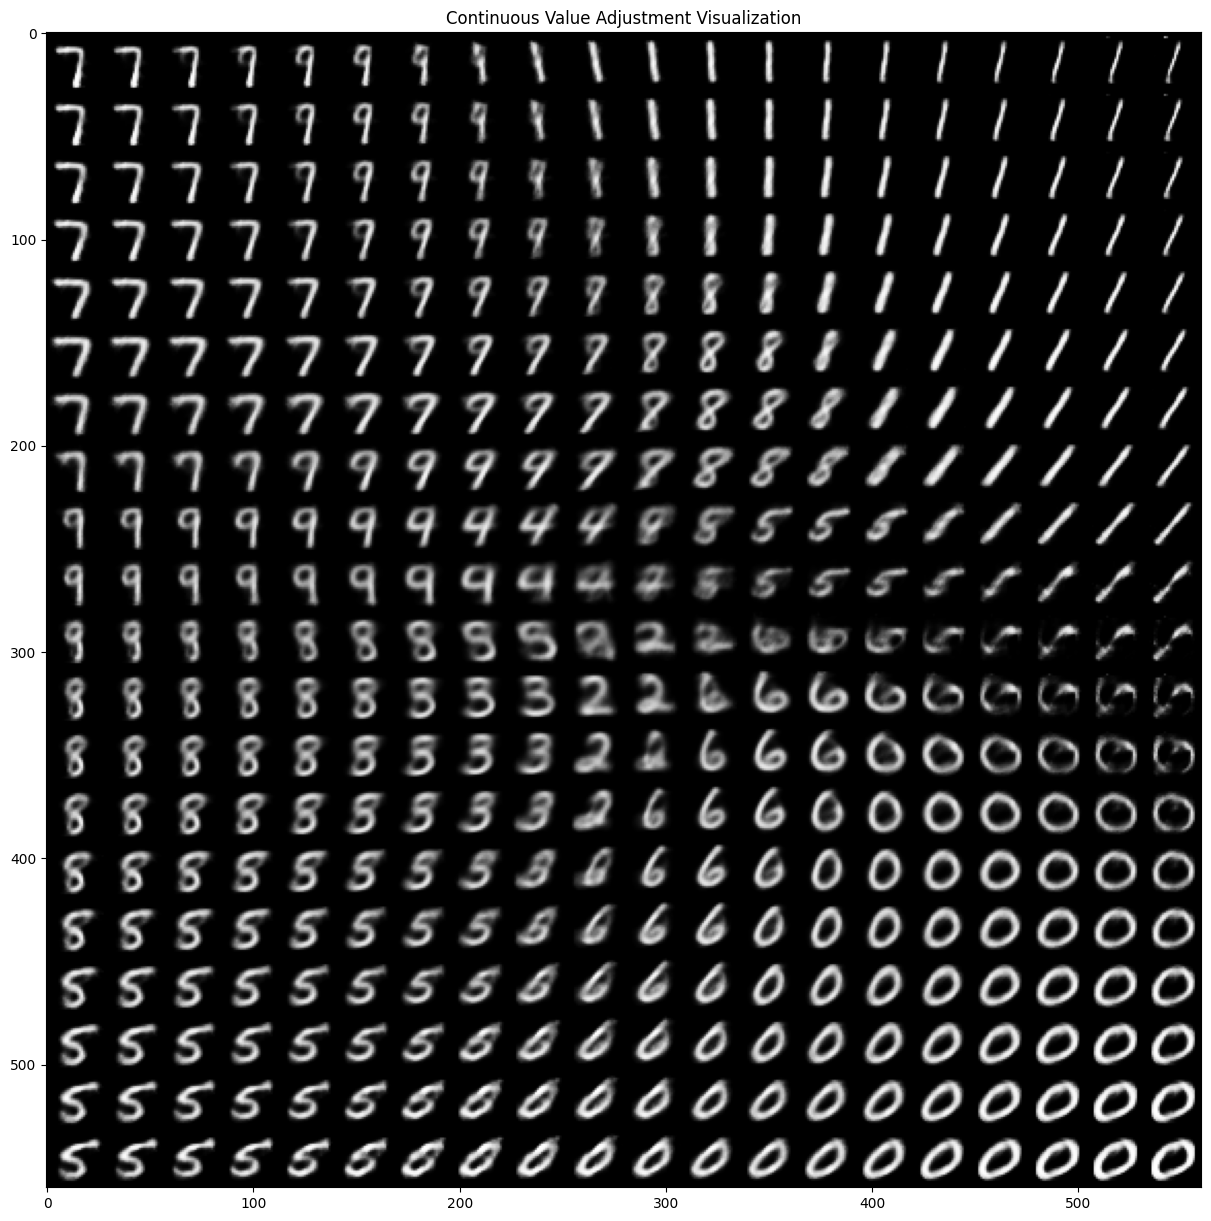

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
# model, device 등은 이전에 정의되었다고 가정합니다.

### 잠재 공간을 활용한 새로운 데이터 생성 (연속적 값 조정) ###
# 이 코드의 목표: "잠재 공간이라는 보물 지도 위를 탐험하며, 각 위치에 어떤 이미지가 숨겨져 있는지 확인해 보자!"
# 인코더를 전혀 사용하지 않고, 오직 '디코더'의 창조 능력만을 활용합니다.

# ==========================================================================================
# 1. 시각화 준비 및 잠재 공간 탐험 계획 수립
# ==========================================================================================

# torch.no_grad() 컨텍스트 매니저를 사용하여 기울기 계산을 비활성화합니다.
# 데이터 생성은 순전히 순전파(forward pass) 과정이므로, 학습(역전파)이 필요 없습니다.
# 이를 통해 메모리 사용량을 줄이고 계산 속도를 높일 수 있습니다.
with torch.no_grad():

    # --- 잠재 공간에 가상의 격자(Grid) 생성 ---
    # 2D 잠재 공간을 탐험할 좌표를 설정합니다.
    # np.linspace(-3, 3, 20): -3부터 3까지의 범위를 20개의 등간격 점으로 나눕니다.
    # 이 범위는 보통 표준 정규분포의 데이터가 대부분 존재하는 (-3σ, +3σ) 구간을 의미합니다.
    # grid_x: 잠재 공간의 1번 차원(x축)을 탐험할 좌표들.
    # grid_y: 잠재 공간의 2번 차원(y축)을 탐험할 좌표들.
    # 결과적으로 20x20, 총 400개의 점을 탐험하게 됩니다.
    # 샘플을 더 늘릴 수도 있다
    grid_x = np.linspace(-3, 3, 20)
    grid_y = np.linspace(-3, 3, 20)

    # --- 생성된 이미지들을 담을 거대한 캔버스 준비 ---
    # 생성될 20x20개의 작은 이미지(각각 28x28 픽셀)를 모두 합쳐 하나의 큰 이미지로 만들 것입니다.
    # np.zeros((28 * 20, 28 * 20)): 가로 560픽셀, 세로 560픽셀 크기의 검은색(0으로 채워진) 캔버스를 생성합니다.
    figure = np.zeros((28 * 20, 28 * 20))

    # ==========================================================================================
    # 2. 잠재 공간 격자 순회 및 이미지 생성
    # 역할: 격자의 각 점(좌표)을 디코더에 입력하여 해당하는 이미지를 생성하고, 캔버스에 붙여넣습니다.
    # ==========================================================================================

    # 중첩 for 루프를 사용하여 20x20 격자의 모든 점을 하나씩 순회합니다.
    # i, yi: 세로축 인덱스(i)와 해당 y 좌표(yi).
    # j, xi: 가로축 인덱스(j)와 해당 x 좌표(xi).
    for i, yi in enumerate(grid_x):
        for j, xi in enumerate(grid_y):
            # --- 1. 현재 좌표를 잠재 벡터 텐서로 변환 ---
            # 현재 격자점의 좌표 (xi, yi)를 잠재 벡터 z로 사용합니다.
            # torch.Tensor([[xi, yi]]): [[xi, yi]] 형태의 PyTorch 텐서를 생성합니다.
            #                              모델 입력 형식에 맞게 배치 차원(1)을 추가하기 위해 이중 대괄호를 사용합니다.
            # .to(device): 생성된 텐서를 모델이 있는 장치(GPU 또는 CPU)로 보냅니다.
            z_sample = torch.Tensor([[xi, yi]]).to(device)

            # --- 2. 디코더를 통해 이미지 생성 (마법의 순간!) ---
            # 준비된 잠재 벡터 z_sample을 학습된 디코더에 입력합니다.
            # 디코더는 이 2차원 좌표를 해석하여 784차원의 이미지 데이터로 '창조'해냅니다.
            x_decoded = model.decode(z_sample)

            # --- 3. 생성된 이미지를 캔버스에 붙이기 위한 후처리 ---
            # .view(28, 28): 디코더가 출력한 1차원 벡터(784)를 다시 28x28 크기의 2차원 이미지로 변환합니다.
            # .cpu().numpy(): 시각화를 위해 텐서를 CPU로 이동시킨 후 NumPy 배열로 변환합니다.
            digit = x_decoded.view(28, 28).cpu().numpy()

            # --- 4. 캔버스의 올바른 위치에 이미지 삽입 ---
            # NumPy 슬라이싱을 사용하여 560x560 캔버스의 정확한 위치에 28x28 크기의 생성된 이미지를 붙여넣습니다.
            # 예: 첫 번째 루프(i=0, j=0)에서는 figure[0:28, 0:28] 위치에 이미지가 들어갑니다.
            #     두 번째 루프(i=0, j=1)에서는 figure[0:28, 28:56] 위치에 이미지가 들어갑니다.
            figure[i * 28: (i + 1) * 28,
                   j * 28: (j + 1) * 28] = digit

    # ==========================================================================================
    # 3. 최종 결과 시각화
    # ==========================================================================================

    # 완성된 560x560 캔버스를 시각화합니다.
    plt.figure(figsize=(15, 15)) # 그림의 크기를 15x15 인치로 크게 설정합니다.

    # plt.imshow()를 사용하여 NumPy 배열을 이미지로 표시합니다.
    # cmap='gray': 이미지를 흑백(grayscale)으로 표시합니다.
    plt.imshow(figure, cmap='gray')

    plt.title('Continuous Value Adjustment Visualization') # 그래프 제목 설정
    plt.show() # 최종 이미지를 화면에 출력합니다.

# 이 결과 이미지를 보면, 잠재 공간의 한 위치에서 다른 위치로 이동할 때
# 숫자의 형태가 점진적이고 부드럽게 변하는 것을 관찰할 수 있습니다.
# 예를 들어, 숫자 '1'이 모여있는 영역에서 '7'이 모여있는 영역으로 이동하면,
# '1'의 형태가 서서히 '7'의 형태로 변해가는 놀라운 광경을 볼 수 있습니다.
# 이것이 바로 VAE가 데이터의 '연속적인 특징'을 학습했다는 강력한 증거입니다.

In [ ]:
import torch
import torch.optim as optim
# VAE, loss_function, trainloader, device 등은 이전에 정의되었다고 가정합니다.

### 잠재 공간 차원 확장: 128D로 재학습 ###

# ==========================================================================================
# 1. 모델 재정의 및 초기화
# 목표: 모델이 이미지를 압축할 때 사용할 '메모장(잠재 공간)'의 크기를 대폭 늘려,
#       더 풍부하고 상세한 정보를 기록할 수 있도록 합니다.
# ==========================================================================================

# --- 핵심 변경점: 잠재 공간 차원(latent_dim)을 128로 설정 ---
# 이전에는 784개의 픽셀 정보를 단 '2개'의 숫자로 압축했습니다 (x, y 좌표).
# 이는 정보를 극심하게 압축해야 하므로, 복원된 이미지가 다소 흐릿하거나 디테일이 뭉개질 수 있습니다.
#
# 이제는 '128개'의 숫자로 정보를 압축합니다.
# 비유하자면, 책 한 권의 내용을 '두 단어'로 요약하던 것에서 '128 단어'로 요약하는 것과 같습니다.
# 당연히 더 많은 정보를 담을 수 있으므로, 이를 바탕으로 책의 내용을 더 정확하게 복원할 수 있게 됩니다.
#
# 기대 효과:
# - 장점: 복원 손실(Reconstruction Loss)이 감소하여, 원본에 더 가까운 선명한 이미지를 생성할 가능성이 높아집니다.
# - 단점: 잠재 공간이 128차원이 되어 더 이상 2D 평면에 시각화할 수 없습니다. (성능과 해석 가능성의 트레이드오프)
latent_dim = 128

# 새로운 잠재 공간 차원으로 VAE 모델 객체를 다시 생성합니다.
# VAE 클래스 내부적으로 fc21, fc22(인코더 출력), fc3(디코더 입력) 레이어의 뉴런 수가 128개로 설정됩니다.
model = VAE(latent_dim=latent_dim).to(device)

# 옵티마이저도 새로 정의된 모델의 파라미터를 관리하도록 다시 설정해 줍니다.
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# 학습 에포크 수도 동일하게 설정합니다.
num_epochs = 100

# ==========================================================================================
# 2. 학습 루프 (Training Loop)
# 역할: 새로운 구조를 가진 모델을 처음부터 다시 학습시킵니다.
# 학습 '과정' 자체는 2D 모델을 학습시킬 때와 완전히 동일합니다.
# 달라진 것은 모델의 '내부 구조'뿐입니다.
# ==========================================================================================

print("128D 잠재 공간으로 학습 시작...")
# 총 num_epochs 만큼 전체 데이터셋을 반복하여 학습합니다.
for epoch in range(num_epochs):

    # 모델을 학습 모드로 설정합니다.
    model.train()

    # 한 에포크의 총 손실을 기록하기 위한 변수를 초기화합니다.
    train_loss = 0

    # 미니배치 단위로 학습을 진행합니다.
    for data, _ in trainloader:

        # 데이터 준비
        data = data.to(device)

        # ★★★ 이전 배치의 기울기 값을 0으로 초기화 (매우 중요) ★★★
        optimizer.zero_grad()

        # 순전파: 데이터가 모델을 통과하여 결과물(복원 이미지, mu, logvar)이 나옵니다.
        # 이때 mu와 logvar는 각각 [배치 크기, 128] 크기의 텐서가 됩니다.
        recon_batch, mu, logvar = model(data)

        # 손실 계산: 결과물과 원본을 비교하여 모델이 얼마나 '못했는지'를 계산합니다.
        # loss_function은 입력 텐서의 크기에 유연하게 동작하므로, 수정 없이 그대로 사용할 수 있습니다.
        loss = loss_function(recon_batch, data, mu, logvar)

        # 역전파: 계산된 손실을 바탕으로 모든 가중치에 대한 기울기를 계산합니다.
        loss.backward()

        # 한 에포크의 총 손실을 누적합니다.
        train_loss += loss.item()

        # 가중치 업데이트: 계산된 기울기를 바탕으로 옵티마이저가 모델의 가중치를 수정하여 '학습'을 진행합니다.
        optimizer.step()

    # 한 에포크 학습이 끝나면 평균 손실을 출력하여 학습 진행 상황을 모니터링합니다.
    # 일반적으로 2D 모델보다 더 낮은 손실 값을 기록할 것으로 예상됩니다.
    # 이는 모델이 더 많은 정보를 활용하여 이미지를 더 잘 복원하고 있음을 의미합니다.
    print(f'Epoch {epoch + 1}, Loss: {train_loss / len(trainloader.dataset)}')

128D 잠재 공간으로 학습 시작...
Epoch 1, Loss: 195.2216832356771
Epoch 2, Loss: 143.7747874674479
Epoch 3, Loss: 130.98689983723958
Epoch 4, Loss: 123.063218359375
Epoch 5, Loss: 117.807070703125
Epoch 6, Loss: 114.47711215820313
Epoch 7, Loss: 112.12387027994792
Epoch 8, Loss: 110.54538473307292
Epoch 9, Loss: 109.35741735026042
Epoch 10, Loss: 108.36710467122396
Epoch 11, Loss: 107.66331513671875
Epoch 12, Loss: 107.08734469401041
Epoch 13, Loss: 106.61035455729167
Epoch 14, Loss: 106.19964912109376
Epoch 15, Loss: 105.87928818359374
Epoch 16, Loss: 105.55672592773438
Epoch 17, Loss: 105.3530421875
Epoch 18, Loss: 105.12999840494791
Epoch 19, Loss: 104.88890559895833
Epoch 20, Loss: 104.69561069335937
Epoch 21, Loss: 104.54886328125
Epoch 22, Loss: 104.40258372395833
Epoch 23, Loss: 104.26582555338541
Epoch 24, Loss: 104.1139794921875
Epoch 25, Loss: 104.00063019205729
Epoch 26, Loss: 103.85263294270834
Epoch 27, Loss: 103.78644949544271
Epoch 28, Loss: 103.66400797526042
Epoch 29, Loss: 103.6

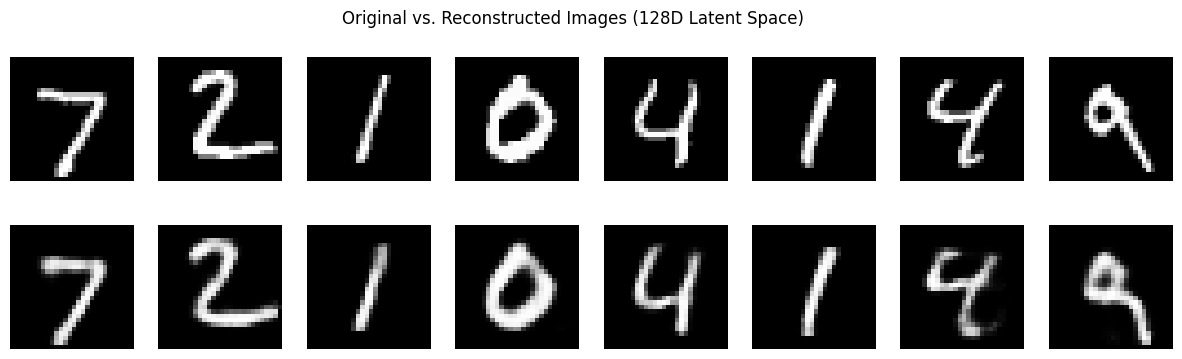

In [ ]:
import torch
import matplotlib.pyplot as plt
# model, testloader, device 등은 이전에 정의되었다고 가정합니다.

### 128D 잠재 공간 재구성 결과 시각화 ###
# 이 코드의 목표: "128차원의 더 넓은 잠재 공간을 사용한 모델이 2D 모델보다 실제로 이미지를 더 잘 복원하는지 눈으로 직접 확인해 보자!"

# ==========================================================================================
# 1. 평가 준비
# ==========================================================================================

# 모델을 '평가 모드'로 설정합니다.
# model.eval()은 학습 시에만 필요한 드롭아웃(Dropout) 등의 기능을 비활성화하여,
# 일관된 추론 결과를 보장합니다.
model.eval()

# torch.no_grad() 컨텍스트 매니저를 사용하여 기울기 계산을 비활성화합니다.
# 재구성 결과만 확인할 것이므로, 역전파나 기울기 계산이 전혀 필요 없습니다.
# 이를 통해 메모리 사용량을 줄이고 계산 속도를 높일 수 있습니다.
with torch.no_grad():

    # ==========================================================================================
    # 2. 테스트 데이터 한 묶음 가져오기 및 재구성
    # ==========================================================================================

    # testloader에서 데이터 한 묶음(미니배치)을 가져옵니다.
    # iter(testloader): testloader를 반복 가능한 객체(iterator)로 만듭니다.
    # next(...): iterator에서 다음 항목(여기서는 첫 번째 미니배치)을 가져옵니다.
    # data: 이미지 데이터 텐서 (예: [64, 1, 28, 28] 크기)
    # _: 해당 이미지의 레이블. 여기서는 사용하지 않으므로 무시합니다.
    data, _ = next(iter(testloader))

    # 가져온 데이터 묶음을 모델이 있는 장치(GPU 또는 CPU)로 보냅니다.
    data = data.to(device)

    # --- 모델을 통과시켜 이미지 재구성 ---
    # 모델의 forward 함수를 실행하여 재구성된 이미지(recon), 평균(mu), 로그 분산(logvar)을 얻습니다.
    # 지금은 재구성된 이미지만 필요하므로, mu와 logvar는 _ 로 받아 무시합니다.
    recon, _, _ = model(data)

    # --- 시각화를 위한 후처리 ---
    # Matplotlib으로 시각화하기 위해 재구성된 이미지 텐서를 NumPy 배열로 변환합니다.
    # .view(-1, 1, 28, 28): recon 텐서는 [64, 784] 형태로 출력되었을 수 있으므로,
    #                      이를 다시 이미지 형태인 [64, 1, 28, 28] (배치 크기, 채널 수, 높이, 너비)로 바꿔줍니다.
    # .cpu(): 만약 텐서가 GPU에 있다면, 먼저 CPU로 이동시킵니다.
    # .numpy(): CPU에 있는 텐서를 NumPy 배열로 변환합니다.
    recon = recon.view(-1, 1, 28, 28).cpu().numpy()

    # ==========================================================================================
    # 3. 원본과 재구성 이미지 비교 시각화
    # ==========================================================================================

    # Matplotlib을 사용하여 여러 개의 이미지를 한 번에 그릴 준비를 합니다.
    # plt.subplots(2, 8, ...): 2행 8열의 총 16개의 서브플롯(작은 그래프 영역)을 생성합니다.
    # fig: 전체 그림(figure) 객체
    # axes: 각 서브플롯에 접근할 수 있는 2x8 크기의 배열
    # figsize=(15, 4): 전체 그림의 크기를 가로 15인치, 세로 4인치로 설정합니다.
    fig, axes = plt.subplots(2, 8, figsize=(15, 4))

    # 8개의 이미지만 비교하기 위해 0부터 7까지 반복합니다.
    for i in range(8):
        # --- 첫 번째 행: 원본 이미지 표시 ---
        # axes[0, i]: 0번 행, i번 열의 서브플롯을 선택합니다.
        # .imshow(...): 선택된 서브플롯에 이미지를 그립니다.
        # data[i]: 현재 미니배치의 i번째 원본 이미지 텐서.
        # .cpu().numpy(): 시각화를 위해 CPU로 보내고 NumPy 배열로 변환합니다.
        # .squeeze(): [1, 28, 28] 형태의 이미지에서 불필요한 채널 차원(1)을 제거하여 [28, 28]로 만듭니다.
        # cmap='gray': 이미지를 흑백으로 표시합니다.
        axes[0, i].imshow(data[i].cpu().numpy().squeeze(), cmap='gray')
        # .axis('off'): 이미지의 축(눈금, 레이블 등)을 제거하여 깔끔하게 보이도록 합니다.
        axes[0, i].axis('off')

        # --- 두 번째 행: 재구성된 이미지 표시 ---
        # axes[1, i]: 1번 행, i번 열의 서브플롯을 선택합니다.
        # recon[i]: i번째 재구성된 이미지 (이미 NumPy 배열입니다).
        # .squeeze(): [1, 28, 28] 형태에서 [28, 28]로 차원을 축소합니다.
        axes[1, i].imshow(recon[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')

    # 전체 그림의 상단에 큰 제목을 추가합니다.
    plt.suptitle("Original vs. Reconstructed Images (128D Latent Space)")

    # 최종적으로 완성된 비교 이미지를 화면에 보여줍니다.
    # 이 결과를 보면, 2D 잠재 공간으로 학습했을 때보다 이미지가 훨씬 선명하고
    # 원본의 디테일을 잘 살려 복원된 것을 확인할 수 있을 것입니다.
    plt.show()